In [2]:
import pandas as pd
import matplotlib.pyplot as plt

stock = pd.read_csv(r"C:\Users\praful\Desktop\madhulika\sentiment stock analysis\data\gme_stock_clean.csv")
reddit = pd.read_csv(r"C:\Users\praful\Desktop\madhulika\sentiment stock analysis\data\gme_reddit_clean.csv")

print("Stock shape:", stock.shape)
print("Reddit shape:", reddit.shape)
print("\nStock date range:", stock['Date'].min(), "to", stock['Date'].max())
print("Reddit date range:", reddit['date'].min(), "to", reddit['date'].max())

Stock shape: (38, 6)
Reddit shape: (106930, 5)

Stock date range: 2021-01-04 to 2021-02-26
Reddit date range: 2012-06-01 to 2021-02-16


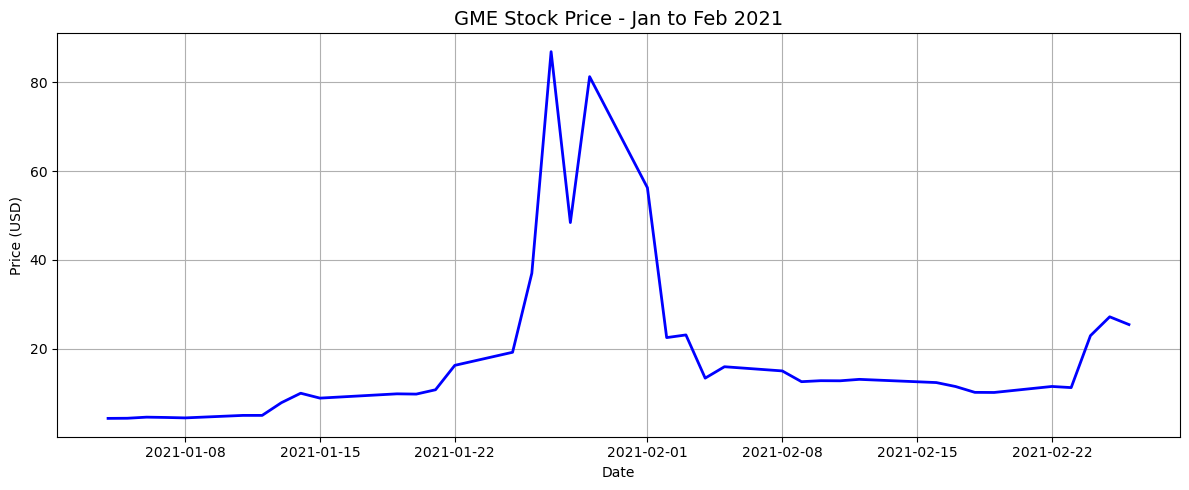

In [3]:
stock['Date'] = pd.to_datetime(stock['Date'])
reddit['date'] = pd.to_datetime(reddit['date'])

# ME Stock Price Over Time
plt.figure(figsize=(12, 5))
plt.plot(stock['Date'], stock['Close'], color='blue', linewidth=2)
plt.title('GME Stock Price - Jan to Feb 2021', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

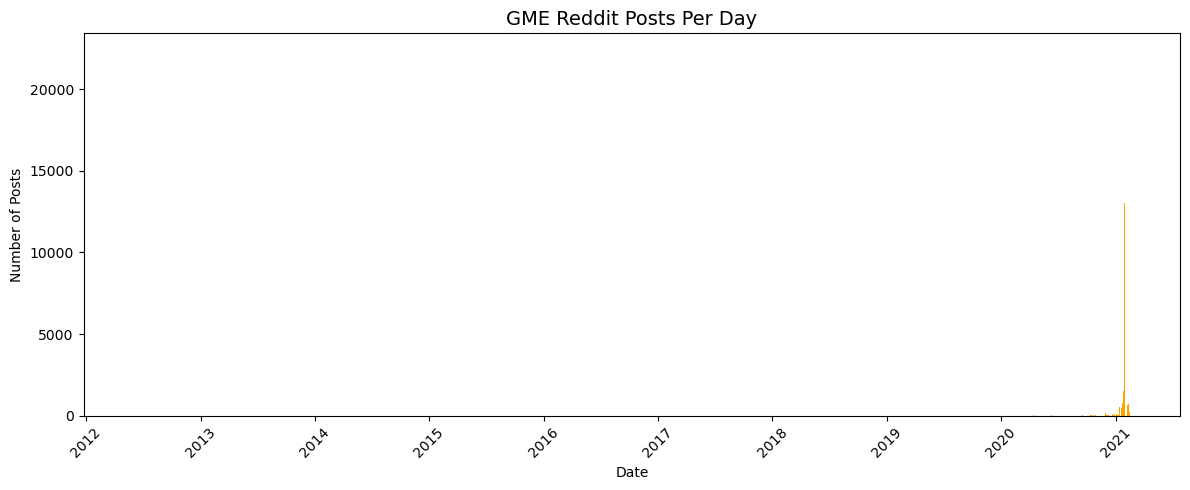

In [4]:
# Count posts per day
posts_per_day = reddit.groupby('date').size().reset_index(name='post_count')
plt.figure(figsize=(12, 5))
plt.bar(posts_per_day['date'], posts_per_day['post_count'], color='orange')
plt.title('GME Reddit Posts Per Day', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

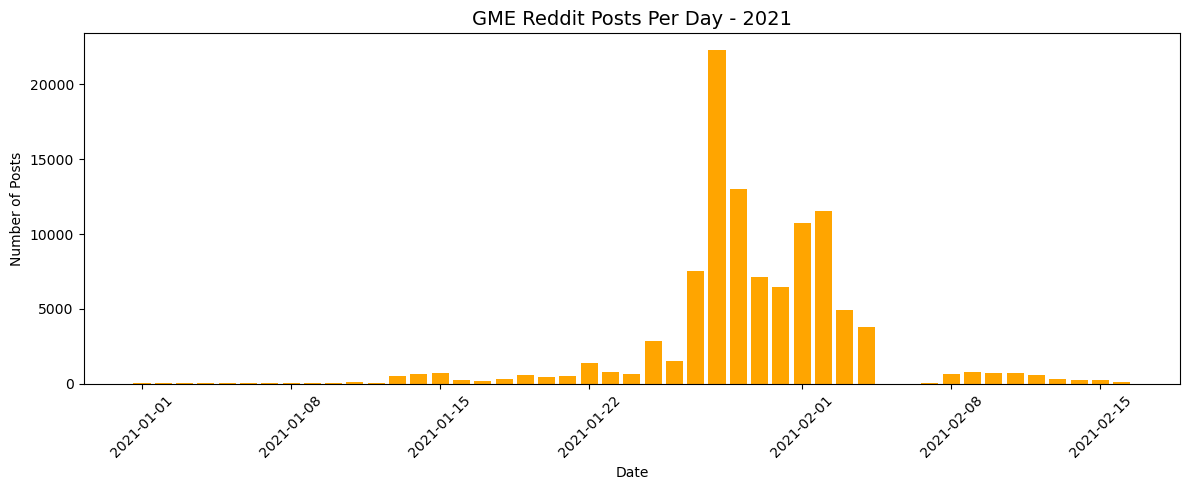

In [5]:
#Filtering only 2021 data
reddit_2021 = reddit[reddit['date'].dt.year == 2021]
posts_per_day = reddit_2021.groupby('date').size().reset_index(name='post_count')
plt.figure(figsize=(12, 5))
plt.bar(posts_per_day['date'], posts_per_day['post_count'], color='orange')
plt.title('GME Reddit Posts Per Day - 2021', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

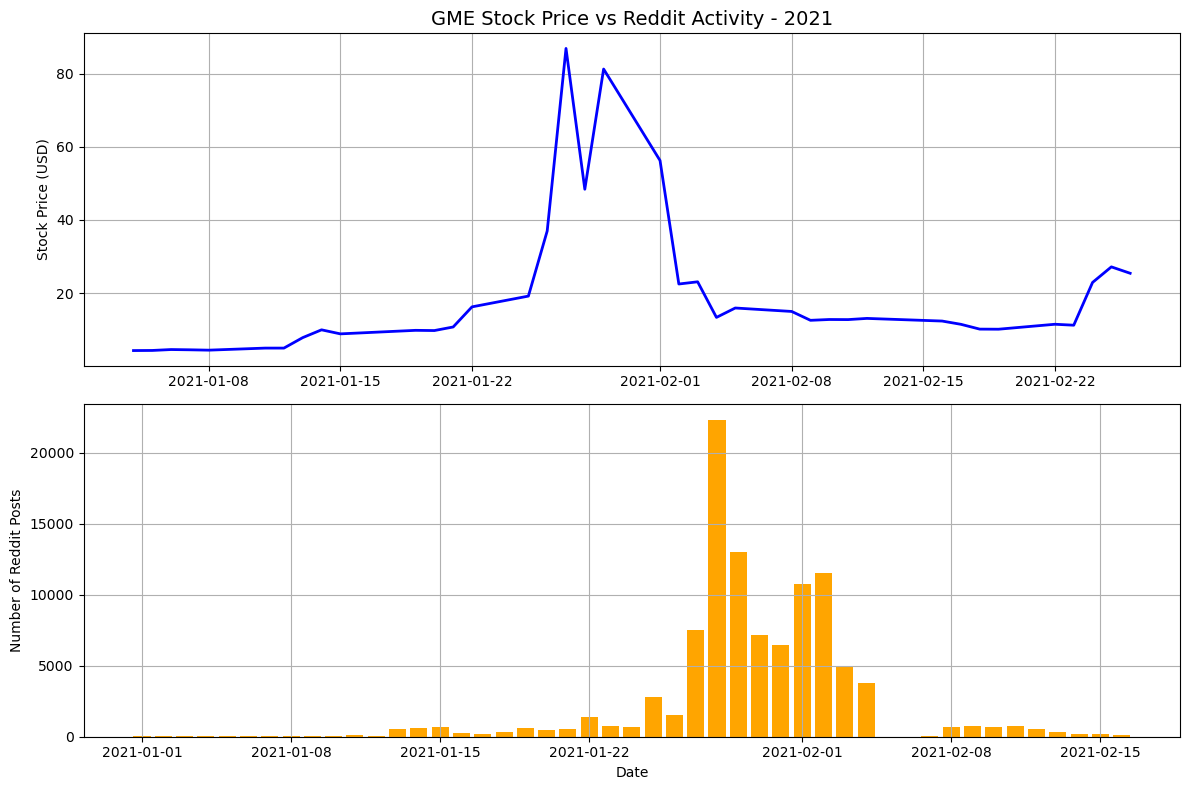

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
#Top chart->Stock Price
ax1.plot(stock['Date'], stock['Close'], color='blue', linewidth=2)
ax1.set_title('GME Stock Price vs Reddit Activity - 2021', fontsize=14)
ax1.set_ylabel('Stock Price (USD)')
ax1.grid(True)

#Bottom chart-> Reddit Posts
posts_per_day = reddit_2021.groupby('date').size().reset_index(name='post_count')
ax2.bar(posts_per_day['date'], posts_per_day['post_count'], color='orange')
ax2.set_ylabel('Number of Reddit Posts')
ax2.set_xlabel('Date')
ax2.grid(True)

plt.tight_layout()
plt.show()

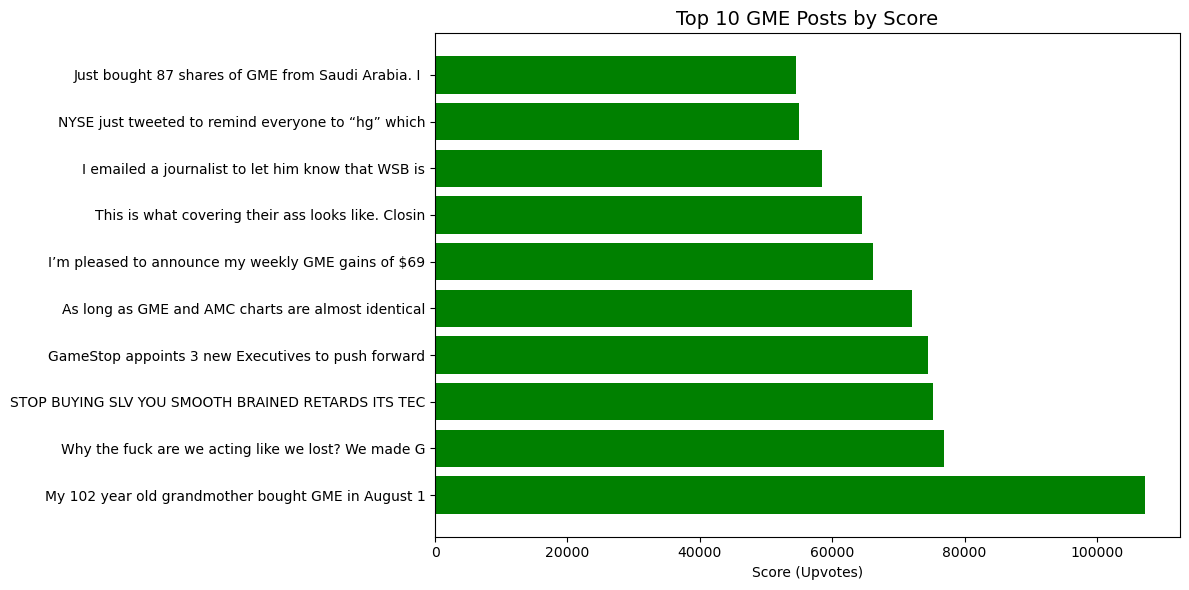

In [7]:
#Top 10 highest scored GME posts
top_posts = reddit_2021.nlargest(10, 'score')[['title', 'score']]
plt.figure(figsize=(12, 6))
plt.barh(top_posts['title'].str[:50], top_posts['score'], color='green')
plt.title('Top 10 GME Posts by Score', fontsize=14)
plt.xlabel('Score (Upvotes)')
plt.tight_layout()
plt.show()